# Introduction to Python for Finance

<a href="https://colab.research.google.com/github/bensonmacharia/ML/blob/main/numpy_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demonstrate loading of data and analysing it

### Import packages

In [55]:
import yfinance as yf
import pandas as pd
from pandas_datareader import data as pdr
import numpy as np
import datetime as dt

### Declare date range for our stock returns

In [56]:
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*5)
startDate, endDate

(datetime.datetime(2021, 5, 15, 21, 13, 48, 765665),
 datetime.datetime(2026, 5, 14, 21, 13, 48, 765665))

### Create list of stocks we are interested in and get data from Yahoo Finance

In [57]:
stocks = ['MSFT', 'SPY', 'QQQ']

df = yf.download(stocks, start=startDate, end=endDate, auto_adjust=True)['Close']
df.head()

[*********************100%***********************]  3 of 3 completed


Ticker,MSFT,QQQ,SPY
Date,,,
2021-05-17,235.264832,314.817261,388.088623
2021-05-18,233.249741,312.692078,384.744995
2021-05-19,233.826782,313.051025,383.736176
2021-05-20,237.058350,319.106506,387.864410
2021-05-21,235.798447,317.340363,387.546875


### Calculate the daily returns

In [58]:
# Log returns for each stock
log_returns = np.log(df / df.shift(1))
log_returns.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2021-05-17,NaN,NaN,NaN
2021-05-18,-0.008602,-0.006773,-0.008653
2021-05-19,0.002471,0.001147,-0.002625
2021-05-20,0.013726,0.019159,0.010701
2021-05-21,-0.005329,-0.005550,-0.000819


### Calculate the cumulative returns

In [59]:
# Cumulative log returns
cumulative_log_returns = log_returns.cumsum()
cumulative_log_returns.head()

Ticker,MSFT,QQQ,SPY
Date,,,
2021-05-17,NaN,NaN,NaN
2021-05-18,-0.008602,-0.006773,-0.008653
2021-05-19,-0.006131,-0.005626,-0.011278
2021-05-20,0.007594,0.013533,-0.000578
2021-05-21,0.002266,0.007983,-0.001397


### Plot cumulative returns

<Axes: title={'center': 'Cumulative Returns'}, xlabel='Date'>

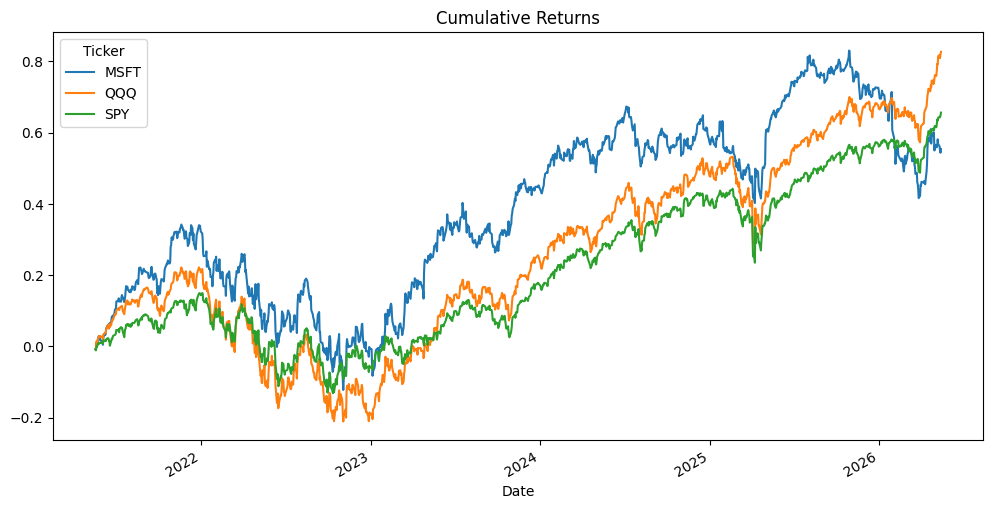

In [60]:
cumulative_log_returns.plot(figsize=(12, 6), title='Cumulative Returns')